/home/wangshu/project/software/miniconda3/envs/copt/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/wangshu/project/software/miniconda3/envs/copt/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


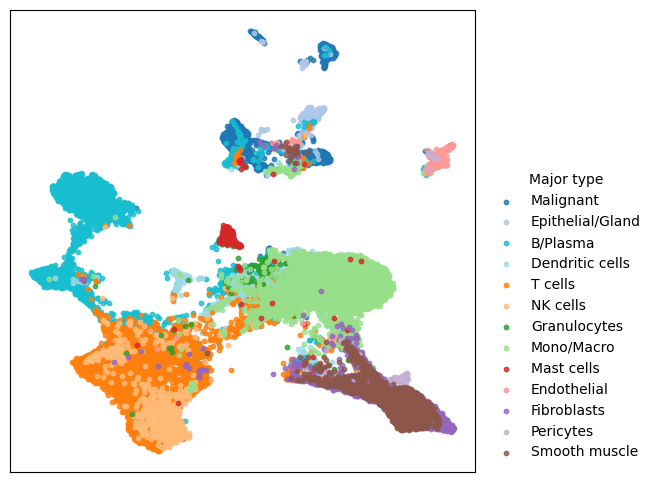

/home/wangshu/project/software/miniconda3/envs/copt/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/wangshu/project/software/miniconda3/envs/copt/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


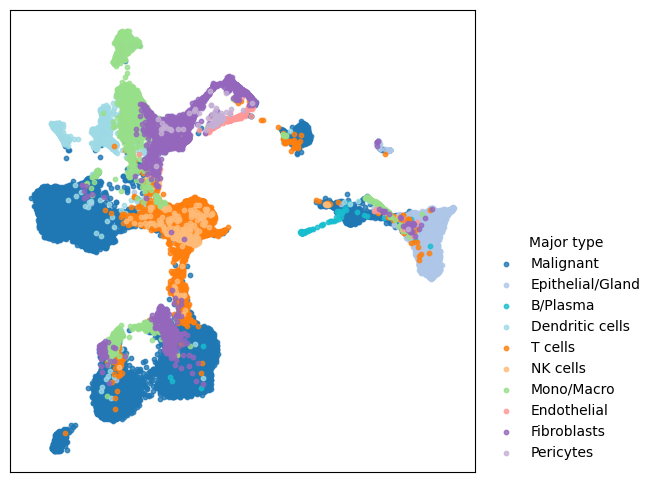

/home/wangshu/project/software/miniconda3/envs/copt/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/wangshu/project/software/miniconda3/envs/copt/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


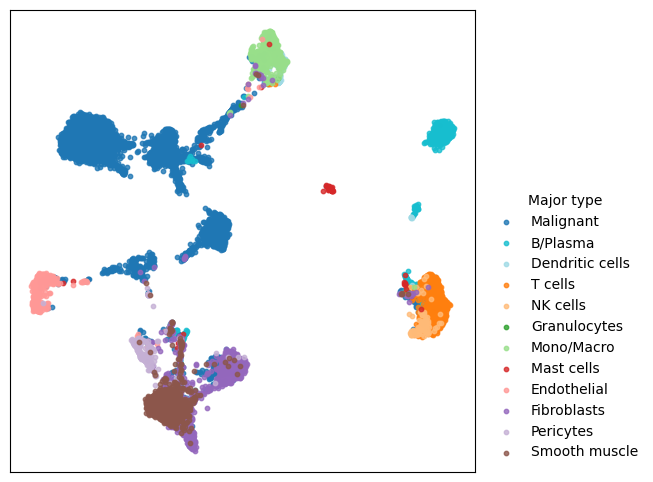

/home/wangshu/project/software/miniconda3/envs/copt/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/wangshu/project/software/miniconda3/envs/copt/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


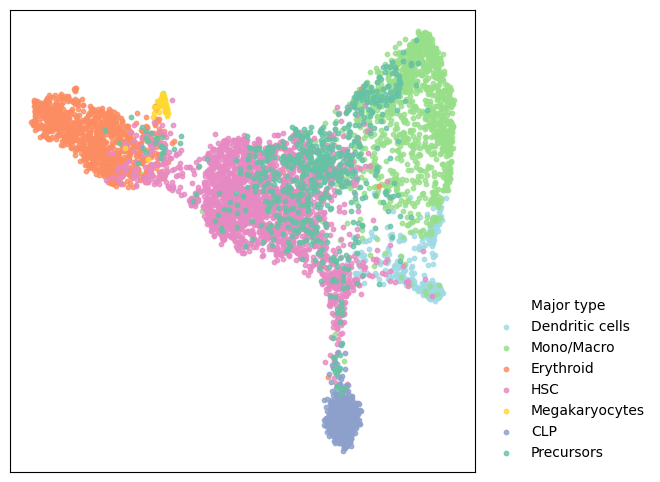

In [ ]:
import umap
import matplotlib.pyplot as plt
import numpy as np
import pickle
import os
os.chdir(os.path.abspath(".."))

major_groups = {
    "CLP": ["CLP"],
    "Erythroid": ["Ery_1", "Ery_2"],
    "HSC": ["HSC_1", "HSC_2"],
    "Megakaryocytes": ["Mega"],
    "Precursors": ["Precursors"],

    # immune 
    "T cells": [
        "CD4-positive, alpha-beta memory T cell",
        "activated CD8-positive, alpha-beta T cell",
        "cytotoxic T cell",
        "natural T-regulatory cell",
        "regulatory T cell",
    ],
    "NK cells": ["natural killer cell"],
    "B/Plasma": ["plasma cell"],
    "Dendritic cells": [
        "conventional dendritic cell",
        "dendritic cell, human",
        "plasmacytoid dendritic cell",
        "plasmacytoid dendritic cell, human",
        "DCs",
    ],
    "Mono/Macro": [
        "Mono_1",
        "Mono_2",
        "classical monocyte",
        "macrophage",
    ],
    "Granulocytes": ["granulocyte"],
    "Mast cells": ["mast cell"],

    # stromal / vascular
    "Endothelial": ["capillary endothelial cell"],
    "Fibroblasts": ["fibroblast of breast", "fibroblast of lung", "muscle fibroblast"],
    "Pericytes": ["pericyte"],
    "Smooth muscle": ["smooth muscle cell"],

    # epithelial / gland
    "Epithelial/Gland": [
        "epithelial cell of lung",
        "basal cell of epithelium of lobular bronchiole",
        "mucous cell of stomach",
        "parietal cell",
        "salivary gland glandular cell",
    ],

    # malignant
    "Malignant": ["malignant cell"],
}

fine2major = {fine: major for major, fines in major_groups.items() for fine in fines}

TAB20 = list(plt.cm.tab20.colors)
Set2 = list(plt.cm.Set2.colors)
Set3 = list(plt.cm.Set3.colors)
color_map = {
    "Malignant": TAB20[0],
    "Epithelial/Gland": TAB20[1],
    "B/Plasma": TAB20[18],
    "Dendritic cells": TAB20[19],
    
    "T cells": TAB20[2],
    "NK cells": TAB20[3],

    "Granulocytes": TAB20[4],
    "Mono/Macro": TAB20[5],
    "Mast cells": TAB20[6],

    "Endothelial": TAB20[7],
    "Fibroblasts": TAB20[8],
    "Pericytes": TAB20[9],
    "Smooth muscle": TAB20[10],

    
    "Other": (0.6, 0.6, 0.6),

    # bonemarrow 专用大类
    "Erythroid": Set2[1],
    "HSC": Set2[3],
    "Megakaryocytes": Set2[5],
    "CLP": Set2[2],
    "Precursors": Set2[0],
}

fallback_pool = [c for c in TAB20 if c not in set(color_map.values())]
fallback_idx = 0

def get_color_for_label(lbl: str):
    global fallback_idx
    if lbl in color_map:
        return color_map[lbl]
    if fallback_idx >= len(fallback_pool):
        fallback_idx = 0
    color_map[lbl] = fallback_pool[fallback_idx]
    fallback_idx += 1
    return color_map[lbl]
# ==============================================

DATA_list = ['Lung', 'DLBCL', 'BC4_FLEX', 'bonemarrow'] #

for data_name in DATA_list:
    with open(f'Result/Cell_level_task/{data_name}_embedding.pkl', 'rb') as f:
        cell = pickle.load(f)

    emb = cell['embedding']
    label_fine = np.asarray(cell['label'])
    label_major = np.array([fine2major.get(str(x), "Other") for x in label_fine], dtype=object)

    # UMAP
    umap_model = umap.UMAP(random_state=42)
    emb_2d = umap_model.fit_transform(emb)
    present = set(np.unique(label_major).tolist())
    unique_major = [k for k in color_map.keys() if k in present]
    unique_major += sorted([k for k in present if k not in color_map])

    fig, ax = plt.subplots(figsize=(6, 6))

    for lab in unique_major:
        mask = (label_major == lab)
        ax.scatter(
            emb_2d[mask, 0], emb_2d[mask, 1],
            label=lab,
            color=get_color_for_label(lab),
            s=10, alpha=0.8
        )

    ax.set_xticks([])
    ax.set_yticks([])
    ax.legend(bbox_to_anchor=(1.01, 0), loc='lower left', fontsize=10,
                frameon=False, title="Major type")

    plt.show()